In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Lambda, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

In [3]:
# Load the MNIST dataset
(x_train, _), (_, _) = mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

img_shape = (28, 28, 1)
latent_dim = 16

In [4]:
# ======================
# Encoder (VAE style)
# ======================
encoder_input = Input(shape=img_shape)
x = Flatten()(encoder_input)
x = Dense(512, activation="relu")(x)
z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = Lambda(sampling)([z_mean, z_log_var])
encoder = Model(encoder_input, [z_mean, z_log_var, z])

In [5]:
# ======================
# Decoder (Generator)
# ======================
decoder_input = Input(shape=(latent_dim,))
x = Dense(512, activation="relu")(decoder_input)
x = Dense(int(np.prod(img_shape)), activation="tanh")(x)
decoder_output = Reshape(img_shape)(x)
decoder = Model(decoder_input, decoder_output)

In [6]:
# ======================
# Discriminator (IMAGE space)
# ======================
disc_input = Input(shape=img_shape)
x = Flatten()(disc_input)
x = Dense(512, activation="relu")(x)
disc_output = Dense(1, activation="sigmoid")(x)
discriminator = Model(disc_input, disc_output)
discriminator.compile(loss="binary_crossentropy", optimizer=Adam(0.0002, 0.5), metrics=["accuracy"])

In [7]:
# ======================
# VAE-GAN combined model
# ======================
discriminator.trainable = False
z_mean, z_log_var, z = encoder(encoder_input)
recon_img = decoder(z)
validity = discriminator(recon_img)

class VAEGANLossLayer(Layer):
    def __init__(self, adv_weight=1e-3):
        super().__init__()
        self.adv_weight = adv_weight

    def call(self, inputs):
        encoder_input, recon_img, z_mean, z_log_var, validity = inputs

        # Reconstruction loss
        recon_loss = tf.reduce_mean(tf.square(encoder_input - recon_img), axis=[1, 2, 3])
        recon_loss *= 28 * 28

        # KL loss
        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = -0.5 * tf.reduce_sum(kl_loss, axis=1)

        # Adversarial loss
        adv_loss = tf.keras.losses.binary_crossentropy(tf.ones_like(validity), validity)
        adv_loss = tf.reduce_mean(adv_loss)

        # Total loss
        total_loss = tf.reduce_mean(recon_loss + kl_loss) + self.adv_weight * adv_loss
        self.add_loss(total_loss)
        return recon_img
    
vae_output = VAEGANLossLayer(adv_weight=1e-3)([encoder_input, recon_img, z_mean, z_log_var, validity])
vae_gan = Model(encoder_input, [vae_output, validity])
vae_gan.compile(optimizer=Adam(0.0002, 0.5))

In [8]:
# ======================
# Training
# ======================
batch_size = 128
epochs = 1000

for epoch in range(epochs):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    imgs = x_train[idx]

    # ---------------------
    # Train Discriminator
    # ---------------------
    z_fake = np.random.normal(0, 1, (batch_size, latent_dim))
    gen_imgs = decoder.predict(z_fake, verbose=0)

    d_loss_real = discriminator.train_on_batch(imgs, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(gen_imgs, np.zeros((batch_size, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ---------------------
    # Train VAE-GAN
    # ---------------------
    g_loss = vae_gan.train_on_batch(imgs, None)

    print(f"Epoch {epoch+1}/{epochs} | D: {d_loss[0]:.4f} | G: {g_loss:.4f}")

/Users/tomcuel/.venvs/global_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1/1000 | D: 0.7738 | G: 894.5155
Epoch 2/1000 | D: 0.7808 | G: 847.9572
Epoch 3/1000 | D: 0.7789 | G: 818.0108
Epoch 4/1000 | D: 0.7825 | G: 795.8235
Epoch 5/1000 | D: 0.7770 | G: 778.4982
Epoch 6/1000 | D: 0.7768 | G: 761.9274
Epoch 7/1000 | D: 0.7734 | G: 745.0609
Epoch 8/1000 | D: 0.7734 | G: 728.3260
Epoch 9/1000 | D: 0.7745 | G: 712.1385
Epoch 10/1000 | D: 0.7708 | G: 694.8048
Epoch 11/1000 | D: 0.7717 | G: 676.8629
Epoch 12/1000 | D: 0.7703 | G: 659.7906
Epoch 13/1000 | D: 0.7689 | G: 643.5067
Epoch 14/1000 | D: 0.7696 | G: 626.7612
Epoch 15/1000 | D: 0.7720 | G: 611.2532
Epoch 16/1000 | D: 0.7713 | G: 596.5951
Epoch 17/1000 | D: 0.7727 | G: 582.5734
Epoch 18/1000 | D: 0.7729 | G: 569.0591
Epoch 19/1000 | D: 0.7727 | G: 557.1465
Epoch 20/1000 | D: 0.7728 | G: 545.4268
Epoch 21/1000 | D: 0.7736 | G: 534.4211
Epoch 22/1000 | D: 0.7734 | G: 523.7230
Epoch 23/1000 | D: 0.7722 | G: 514.4693
Epoch 24/1000 | D: 0.7718 | G: 505.1831
Epoch 25/1000 | D: 0.7712 | G: 496.4227
Epoch 26/

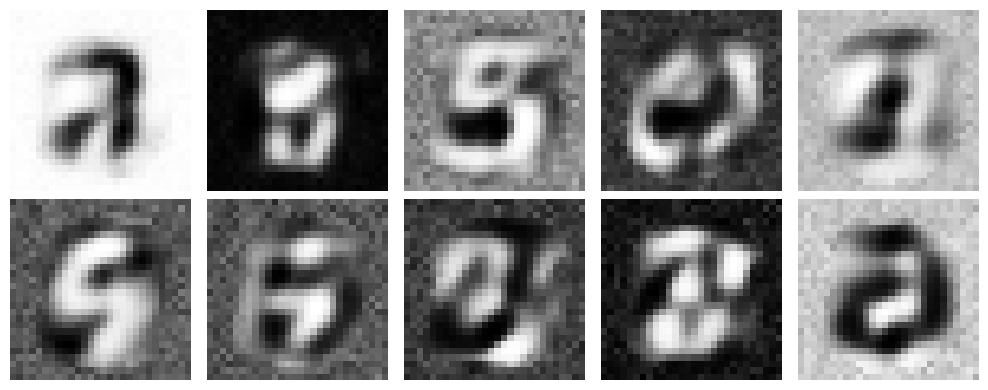

In [9]:
# ======================
# Sampling
# ======================
def display_images(n=10):
    z_sample = np.random.normal(0, 1, (n, latent_dim))
    gen_imgs = decoder.predict(z_sample, verbose=0)

    plt.figure(figsize=(10, 4))
    for i in range(n):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(gen_imgs[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

display_images()